# Mimicking RouteLLM

### Generate embeddings

In [ ]:
import os
import json
import requests
import numpy as np

results_path = '../AutoFL/results/d4j_autofl_eol_1/llama3'
initial_prompts_path = 'route_data/initial_prompts.json'
trimmed_prompts_path = 'route_data/trimmed_prompts.json'
endpoint = 'http://localhost:11434/api/embeddings'
embeddings_path = 'route_data/embeddings.json'

In [2]:
initial_prompt_dict = dict()
for file in sorted(os.listdir(results_path)):
    with open(os.path.join(results_path, file)) as f:
        msgs = json.load(f)['messages']
        bug_id = file[4:-5]
        initial_prompt = msgs[0]['content'] + msgs[1]['content']
        initial_prompt_dict[bug_id] = initial_prompt

# with open(initial_prompts_path, 'w') as f:
#     json.dump(initial_prompt_dict, f, indent=4)

In [ ]:
with open(initial_prompts_path) as f:
    initial_prompt_dict = json.load(f)
trimmed_prompt_dict = dict(zip(initial_prompt_dict.keys(), [prompt[prompt.find('The test looks like:'):] for prompt in list(initial_prompt_dict.values())]))

with open(trimmed_prompts_path, 'w') as f:
    json.dump(trimmed_prompt_dict, f, indent=4)

In [ ]:
def _query_model(payload):
    for _ in range(5):
        try:
            json_payload = json.dumps(payload)
            headers = {'Content-Type': 'application/json'}
            response = json.loads(requests.post(endpoint, data=json_payload, headers=headers).text)
            return response['embedding']
        except Exception as e:
            save_err = e
            if "The server had an error processing your request." in str(e):
                time.sleep(1)
            else:
                break
    raise save_err


def get_LLM_response(initial_prompt):
    payload = {
        'model': 'nomic-embed-text',
        'prompt': initial_prompt,
        'stream': False
    }
    return _query_model(payload)

if __name__ == "__main__":
    embeddings_dict = dict()
    with open(initial_prompts_path) as f:
        data = json.load(f)
        
    for bug_id in data:
        initial_prompt = data[bug_id]
        embedding = get_LLM_response(initial_prompt)
        embeddings_dict[bug_id] = embedding
    
    with open(embeddings_path, 'w') as f:
        json.dump(embeddings_dict, f)

### Format vs. results

In [148]:
strong_model_name = 'qwen2.5coder-7b'
weak_model_name = 'llama3-8b'
strong_result_path = '../AutoFL/combined_fl_results/d4j_eol_qwen2.5-coder_R5.json'
weak_result_path = '../AutoFL/combined_fl_results/d4j_eol_llama3_R5.json'

In [210]:
strong_model_name = 'mistral-nemo-12b'
weak_model_name = 'qwen2.5coder-7b'
strong_result_path = '../AutoFL/combined_fl_results/d4j_eol_mistral-nemo_R5.json'
weak_result_path = '../AutoFL/combined_fl_results/d4j_eol_qwen2.5-coder_R5.json'

In [290]:
## gpt-4o vs. llama3 config
strong_model_name = 'gpt-4o'
weak_model_name = 'qwen2.5-coder-7b'
strong_result_path = '../AutoFL/combined_fl_results/d4j_gpt4o_results_R10_full.json'
weak_result_path = '../AutoFL/combined_fl_results/d4j_eol_qwen2.5-coder_R10.json'

In [291]:
with open(strong_result_path) as f:
    strong_result = json.load(f)['buggy_methods']

with open(weak_result_path) as f:
    weak_result = json.load(f)['buggy_methods']

def extract_min_ranks(result, bug_list):
    min_ranks = list() 
    for bug_id in bug_list:
        buggy_methods = result[bug_id]
        min_ranks.append(0 if not buggy_methods else min(map(lambda x: x['autofl_rank'], buggy_methods.values())))
    
    return min_ranks    

sorted_bug_list = sorted(strong_result.keys())

strong_ranks = extract_min_ranks(strong_result, sorted_bug_list)
weak_ranks = extract_min_ranks(weak_result, sorted_bug_list)
vs_result = list(map(lambda x: x[0] < x[1], zip(strong_ranks, weak_ranks)))

### Analysis

In [292]:
probs_dir = f'results/cv/{strong_model_name}_{weak_model_name}'
probs = dict()
for i in range(1, 6):
    with open(f'{probs_dir}/fold_{i}.json') as f:
        data = json.load(f)
    probs.update(data)
len(probs)

222

(array([18., 40., 38., 52., 37., 21.,  9.,  2.,  1.,  4.]),
 array([0.21705118, 0.27461703, 0.33218287, 0.38974872, 0.44731457,
        0.50488041, 0.56244626, 0.62001211, 0.67757795, 0.7351438 ,
        0.79270965]),
 <BarContainer object of 10 artists>)

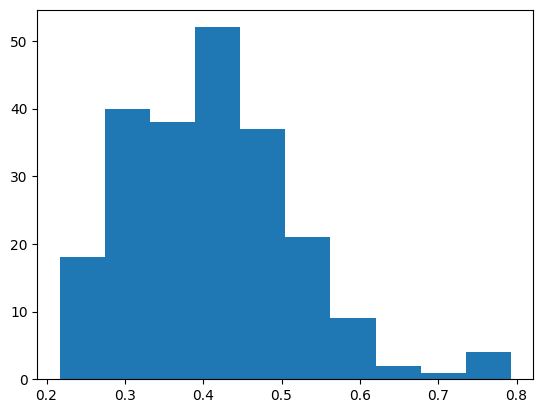

In [293]:
import matplotlib.pyplot as plt
plt.hist(probs.values())

In [294]:
weak_count = len(list(filter(lambda x: x == 1, weak_ranks)))
weak_count

104

In [295]:
strong_count = len(list(filter(lambda x: x == 1, strong_ranks)))
strong_count

164

In [296]:
weak_key_list = list(weak_result.keys())

def acc_at_1_and_weak_model_calls_for_threshold(threshold):
    aggregated_ranks = list()
    strong_model_call_count = 0
    for i, bug_id in enumerate(strong_result):
        if probs[bug_id] > threshold:
            aggregated_ranks.append(strong_ranks[i])
            strong_model_call_count += 1
        else:
            aggregated_ranks.append(weak_ranks[i])
    return len(list(filter(lambda x: x == 1, aggregated_ranks))), strong_model_call_count

In [297]:
list_of_acc_at_1 = list()
strong_model_calls = list()
step_count = 100

for i in range(step_count + 1):
    threshold = (1 / step_count) * i
    acc_at_1, strong_model_call_count = acc_at_1_and_weak_model_calls_for_threshold(threshold)
    list_of_acc_at_1.append(acc_at_1)
    strong_model_calls.append((strong_model_call_count / len(strong_ranks)))

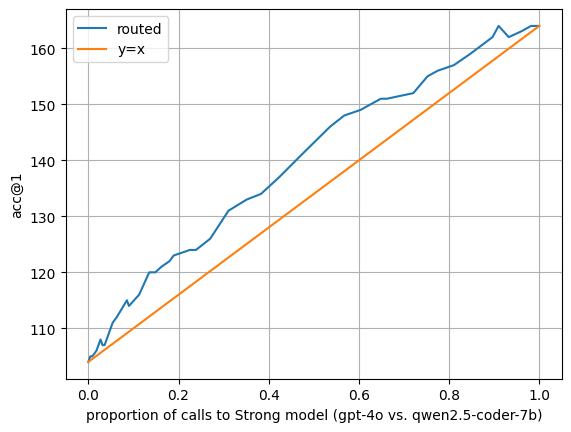

In [298]:
plt.plot(strong_model_calls, list_of_acc_at_1, label='routed')
plt.plot([0.0, 1.0], [weak_count, strong_count], label='y=x')
plt.xlabel(f"proportion of calls to Strong model ({strong_model_name} vs. {weak_model_name})")
plt.ylabel("acc@1")
plt.grid(True)
plt.legend()
plt.show()

### Why the routed performance doesn't go over the strong model's peak performance?  
there seems to be no theoretical barrier here  

In [299]:
prob_of_only_weak_model_gets_correct = [list(probs.values())[i] for i in range(len(probs)) if weak_ranks[i] == 1 and strong_ranks[i] != 1]

In [300]:
prob_of_only_strong_model_gets_correct = [list(probs.values())[i] for i in range(len(probs)) if weak_ranks[i] != 1 and strong_ranks[i] == 1]

In [301]:
len(prob_of_only_strong_model_gets_correct)

72

In [302]:
len(prob_of_only_weak_model_gets_correct)

12

In [303]:
prob_of_both_correct = [list(probs.values())[i] for i in range(len(probs)) if weak_ranks[i] == 1 and strong_ranks[i] == 1]

In [304]:
prob_of_both_incorrect = [list(probs.values())[i] for i in range(len(probs)) if weak_ranks[i] != 1 and strong_ranks[i] != 1]

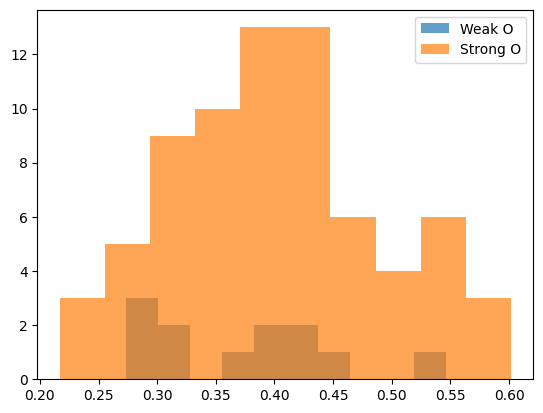

In [305]:
plt.hist(prob_of_only_weak_model_gets_correct, alpha=0.7, label='Weak O')
plt.hist(prob_of_only_strong_model_gets_correct, alpha=0.7, label='Strong O')
plt.legend()

In [306]:
print(f"STRONG\t{np.mean(prob_of_only_strong_model_gets_correct):.2f}\t{np.std(prob_of_only_strong_model_gets_correct):.4f}")
print(f"WEAK\t{np.mean(prob_of_only_weak_model_gets_correct):.2f}\t{np.std(prob_of_only_weak_model_gets_correct):.4f}")

STRONG	0.40	0.0885
WEAK	0.38	0.0781


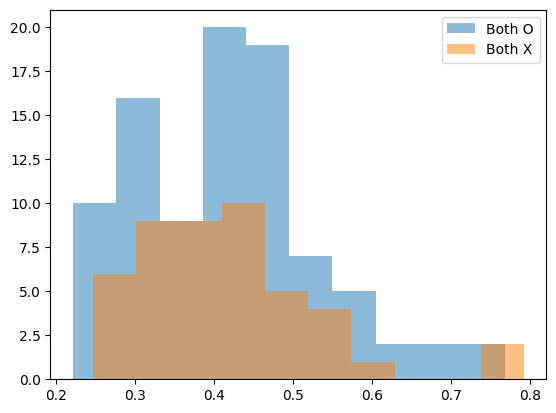

In [307]:
plt.hist(prob_of_both_correct, alpha=0.5, label='Both O')
plt.hist(prob_of_both_incorrect, alpha=0.5, label='Both X')
plt.legend()

In [308]:
print(f"Both O\t{np.mean(prob_of_both_correct):.2f}\t{np.std(prob_of_both_correct):.4f}")
print(f"Both X\t{np.mean(prob_of_both_incorrect):.2f}\t{np.std(prob_of_both_incorrect):.4f}")

Both O	0.42	0.1156
Both X	0.42	0.1135
